In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('default')

In [2]:
print("Step 1")

try:
    excel_file = 'EB-motor crashes (NAIS).xlsx'
    target_sheet = "Sheet1"
    df = pd.read_excel(excel_file, sheet_name=target_sheet)
    
    print(f"✓ : {excel_file}")
    print(f"✓ : {target_sheet}")
    print(f"✓ : {df.shape[0]}  × {df.shape[1]} ")
    
    
    print(f"\nData column name:")  
    for i, col in enumerate(df.columns, 1):
        print(f"  {i:2d}. {col}")
    
    
    missing_count = df.isnull().sum().sum()
    if missing_count == 0:
        print(f"\n✓ Data quality check: No missing values（Missing values: {missing_count}）")
    else:
        print(f"\n✗ Data quality check: Missing Values: {missing_count}")
        missing_detail = df.isnull().sum()
        for col, count in missing_detail[missing_detail > 0].items():
            print(f"    {col}: {count}")
    
   
    X = df.drop('Accident classification', axis=1) 
    y = df['Accident classification']              
    
  
    print(f"\n'Accident Classification 'Distribution:")
    class_dist = y.value_counts().sort_index()
    total_samples = len(y)
    for cls, count in class_dist.items():
        percentage = count / total_samples * 100
        print(f"  {cls}: {count} ({percentage:.1f}%)")
    
  
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
   
    y_train = y_train - 1
    y_test = y_test - 1
   
    print(f"\n✓  Target variable converted successfully:")
    print(f"  Converted trainging set category：{sorted(y_train.unique())}")
    print(f"  Converted test set category：{sorted(y_test.unique())}")
    # ==============================================
    
    print(f"\n✓ Data segmentation is complete:")
    print(f"  Training set: {X_train.shape[0]}samples × {X_train.shape[1]}characteristics")
    print(f"  Test set: {X_test.shape[0]}samples × {X_test.shape[1]}characteristics")
    
   
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
   
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
    
    print(f"✓ Feature standardization completed")
    print("="*60)
    
except Exception as e:
    print(f"\n✗Data processing failed: {str(e)}")
    print("Please check: 1. Whether the file path is correct 2. Whether the sheet name is correct 3. Whether the Excel file is damaged")
    raise

Step 1
✓ : EB-motor crashes (NAIS).xlsx
✓ : Sheet1
✓ : 1026  × 18 

Data column name:
   1. EB rider age
   2. EB rider gender
   3. EB rider illegal fault
   4. Helmet use
   5. Weather
   6. Accident time
   7. Season
   8. Weekend
   9. Vehicle type
  10. Vehicle age
  11. Vehicle maneuver
  12. Driver age
  13. Driver gender
  14. Driving experience
  15. Driver illegal fault
  16. Road surface
  17. Estimated vehicle speed(km/h)
  18. Accident classification

✓ Data quality check: No missing values（Missing values: 0）

'Accident Classification 'Distribution:
  1: 320 (31.2%)
  2: 665 (64.8%)
  3: 41 (4.0%)

✓  Target variable converted successfully:
  Converted trainging set category：[np.int64(0), np.int64(1), np.int64(2)]
  Converted test set category：[np.int64(0), np.int64(1), np.int64(2)]

✓ Data segmentation is complete:
  Training set: 820samples × 17characteristics
  Test set: 206samples × 17characteristics
✓ Feature standardization completed


In [3]:
print("Step 2")


class PSOOptimizer:
    
    def __init__(self, n_particles, max_iter, param_bounds, fitness_func):
        self.n_particles = n_particles  
        self.max_iter = max_iter        
        self.param_bounds = param_bounds
        self.fitness_func = fitness_func
        self.n_params = len(param_bounds)
        
       
        self.positions = np.zeros((n_particles, self.n_params))
        self.velocities = np.zeros((n_particles, self.n_params))
        
        
        for i in range(self.n_params):
            min_val, max_val = param_bounds[i]
            self.positions[:, i] = np.random.uniform(min_val, max_val, n_particles)
            self.velocities[:, i] = np.random.uniform(-0.5, 0.5, n_particles)
        
       
        self.personal_best_pos = self.positions.copy()
        self.personal_best_val = [fitness_func(pos) for pos in self.positions]
        self.global_best_idx = np.argmin(self.personal_best_val)
        self.global_best_pos = self.personal_best_pos[self.global_best_idx].copy()
        self.global_best_val = self.personal_best_val[self.global_best_idx]
        
        
        self.iter_history = []
    
    def update_particles(self, w=0.5, c1=1.5, c2=1.5):
       
        for i in range(self.n_particles):
            r1 = np.random.rand(self.n_params)
            r2 = np.random.rand(self.n_params)
            
            
            cognitive_term = c1 * r1 * (self.personal_best_pos[i] - self.positions[i])
            social_term = c2 * r2 * (self.global_best_pos - self.positions[i])
            self.velocities[i] = w * self.velocities[i] + cognitive_term + social_term
            
          
            self.positions[i] += self.velocities[i]
            for j in range(self.n_params):
                min_val, max_val = self.param_bounds[j]
                self.positions[i][j] = np.clip(self.positions[i][j], min_val, max_val)
            
            
            current_val = self.fitness_func(self.positions[i])
            if current_val < self.personal_best_val[i]:
                self.personal_best_val[i] = current_val
                self.personal_best_pos[i] = self.positions[i].copy()
                
               
                if current_val < self.global_best_val:
                    self.global_best_val = current_val
                    self.global_best_pos = self.positions[i].copy()
    
    def optimize(self):
       
        print(f"PSO optimization configuration:")
        print(f"  Number of particles: {self.n_particles}")
        print(f"  Number of iterations: {self.max_iter}")
        print(f"  Parameter dimension: {self.n_params}")
        print(f"\\nOptimization process:")
        
        for iter in range(self.max_iter):
            self.update_particles()
            self.iter_history.append(self.global_best_val)
            
            
            if (iter + 1) % 10 == 0:
                print(f"  Iteration{iter+1:2d}/{self.max_iter}: Optimal fitness = {self.global_best_val:.4f}")
        
        print(f"\\n PSO optimization completed!")
        print(f"  Optimal fitness value: {self.global_best_val:.4f}")
       
        return self.global_best_pos, self.global_best_val

Step 2


In [4]:
print("Step 3")

def xgboost_fitness_function(params):
    
    
    n_estimators = int(round(params[0]))
    max_depth = int(round(params[1]))
    learning_rate = params[2]
    subsample = params[3]
    colsample_bytree = params[4]
    reg_alpha = params[5]
    reg_lambda = params[6]
    
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        objective='multi:softmax',  
        num_class=len(np.unique(y)),
        random_state=42,
        n_jobs=-1  
    )
    
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    
    
    return -np.mean(cv_scores)


param_bounds = [
    (50, 300),    
    (2, 10),      
    (0.01, 0.3),  
    (0.6, 1.0),   
    (0.6, 1.0),   
    (0, 10),      
    (0, 10)       
]


param_names = [
    'n_estimators', 'max_depth', 'learning_rate', 'subsample',
    'colsample_bytree', 'reg_alpha', 'reg_lambda'
]

print(f"✓ The fitness function has been defined.")
print(f"✓ Optimize parameters: {param_names}")
print(f"✓ Parameter boundaries have been set.")


Step 3
✓ The fitness function has been defined.
✓ Optimize parameters: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'reg_alpha', 'reg_lambda']
✓ Parameter boundaries have been set.


In [5]:
print("Step 4")


try:
    
    pso_optimizer = PSOOptimizer(
        n_particles=20,          
        max_iter=50,             
        param_bounds=param_bounds,
        fitness_func=xgboost_fitness_function
    )
    
    
    best_params, best_fitness = pso_optimizer.optimize()
    
    
    best_params_dict = {}
    for i, name in enumerate(param_names):
        if name in ['n_estimators', 'max_depth']:
            
            best_params_dict[name] = int(round(best_params[i]))
        else:
            
            best_params_dict[name] = round(best_params[i], 4)
    
    
    best_cv_accuracy = -best_fitness
    
    
    print(f"\\nOptimal parameters of XGBoost obtained through PSO optimization:")
    print("-" * 40)
    for name, value in best_params_dict.items():
        print(f"{name:20s}: {value}")
    print("-" * 40)
    print(f"Optimal cross-validation accuracy rate: {best_cv_accuracy:.4f}")
    
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, pso_optimizer.max_iter + 1), 
             [-val for val in pso_optimizer.iter_history],
             linewidth=2.5, marker='o', markersize=4, color='#2E86AB', alpha=0.8)
    plt.xlabel('Number of iterations', fontsize=12, fontweight='bold')
    plt.ylabel('Cross-validation accuracy', fontsize=12, fontweight='bold')
    plt.title('PSO Optimisation Convergence Curve', fontsize=14, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig('pso_convergence_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"\\n✓ The convergence curve of PSO has been saved.")
    
    
except Exception as e:
    print(f"\\n✗ PSO optimization failed: {str(e)}")
    raise

Step 4
PSO optimization configuration:
  Number of particles: 20
  Number of iterations: 50
  Parameter dimension: 7
\nOptimization process:
  Iteration10/50: Optimal fitness = -0.8780
  Iteration20/50: Optimal fitness = -0.8793
  Iteration30/50: Optimal fitness = -0.8793
  Iteration40/50: Optimal fitness = -0.8793
  Iteration50/50: Optimal fitness = -0.8793
\n PSO optimization completed!
  Optimal fitness value: -0.8793
\nOptimal parameters of XGBoost obtained through PSO optimization:
----------------------------------------
n_estimators        : 300
max_depth           : 10
learning_rate       : 0.3
subsample           : 0.7368
colsample_bytree    : 0.9971
reg_alpha           : 0.0
reg_lambda          : 2.4869
----------------------------------------
Optimal cross-validation accuracy rate: 0.8793
\n✓ The convergence curve of PSO has been saved.


In [6]:
print("Step 5")  

try:
    
    xgb_model = XGBClassifier(
        **best_params_dict,
        objective='multi:softmax',    
        num_class=len(np.unique(y_train)),  
        eval_metric='mlogloss',       
        random_state=42,
        n_jobs=-1                     
    )
    
    
    print(f"Configuration of the XGBoost model (optimized by PSO):")
    for key, value in best_params_dict.items():
        
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")
    
    
    print(f"\nStart training the model...")
    xgb_model.fit(X_train_scaled, y_train)  
    
    
    y_pred = xgb_model.predict(X_test_scaled)
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)
    
    
    test_accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n✓ Model training completed!")
    print(f"  Accuracy of the test set: {test_accuracy:.4f}")
    
    
    print(f"\nClassification Report:")
    print("-" * 60)
    class_names = [f'Type of accident{i+1}' for i in sorted(np.unique(y_train))]
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))
    print("-" * 60)
    
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Sample size'})
    plt.xlabel('Prediction', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"✓ Confusion matrix has been saved.")
    
    
    feature_importance = xgb_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Features': X.columns,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    
    
    print(f"\nThe top 10 feature importance of XGBoost:")
    print("-" * 50)
    print(f"{'Rank':<6} {'Feature':<20} {'Importance':<10}")
    print("-" * 50)
    for i in range(min(10, len(feature_importance_df))):
        rank = i + 1
        feature = feature_importance_df.iloc[i]['Features']  
        importance = feature_importance_df.iloc[i]['Importance']
        print(f"{rank:<6} {feature:<20} {importance:<10.4f}")
    print("-" * 50)
    
    
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(15)  
    sns.barplot(x='Importance', y='Features', data=top_features, palette='viridis')  
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.ylabel('Feature', fontsize=12, fontweight='bold')
    plt.title('XGBoost Feature Importance Ranking (Top 15)', fontsize=14, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--', axis='x')
    plt.tight_layout()
    plt.savefig('xgboost_feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"✓ The feature importance graph has been saved.")
    
    
except Exception as e:
    print(f"\n✗ Model training failed: {str(e)}")
    raise

Step 5
Configuration of the XGBoost model (optimized by PSO):
  n_estimators: 300
  max_depth: 10
  learning_rate: 0.3000
  subsample: 0.7368
  colsample_bytree: 0.9971
  reg_alpha: 0.0000
  reg_lambda: 2.4869

Start training the model...

✓ Model training completed!
  Accuracy of the test set: 0.9126

Classification Report:
------------------------------------------------------------
                   precision    recall  f1-score   support

Type of accident1     0.8788    0.9062    0.8923        64
Type of accident2     0.9394    0.9254    0.9323       134
Type of accident3     0.7500    0.7500    0.7500         8

         accuracy                         0.9126       206
        macro avg     0.8561    0.8605    0.8582       206
     weighted avg     0.9132    0.9126    0.9128       206

------------------------------------------------------------
✓ Confusion matrix has been saved.

The top 10 feature importance of XGBoost:
--------------------------------------------------
Rank  

Step 6
Initialize the XGBoost-specific SHAP interpreter...
  Dimension of the test set：206samples × 17characteristics | Number of multi-class categories：3
  Feature name format：<class 'list'>（Pure Python list, length：17）
  Original SHAP value shape：(206, 17, 3) 
  After format conversion：list length=3 | Shape of the SHAP value for a single category=(206, 17)
  SHAP expected value(expected_value)：<class 'list'>，length=3

Generate a summary chart of SHAP feature importance...
✓ The SHAP summary graph has been saved.

Generate the optimal feature dependency graph of SHAP...
  Optimal features of the model: Vehicle type（Index: 8）


<Figure size 1000x600 with 0 Axes>

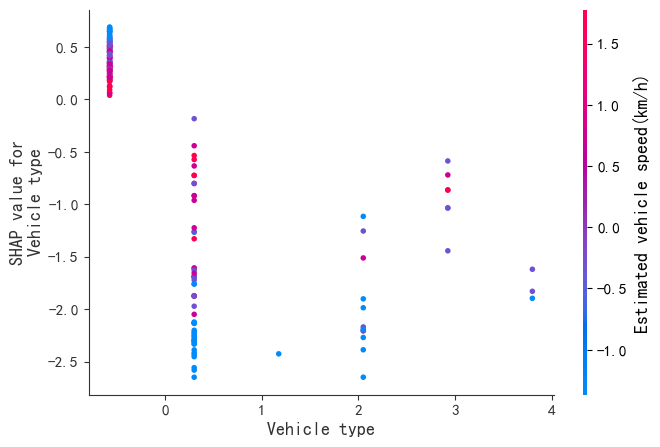

✓ SHAP dependency graph has been saved: shap_dependence_Vehicle type.png

Generate SHAP single-sample forces...


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


  ✓ Sample1force graphs have been saved.
  ✓ Sample2force graphs have been saved.
  ✓ Sample3force graphs have been saved.
  ✓ Sample4force graphs have been saved.
  ✓ Sample5force graphs have been saved.

Generate SHAP decision graph (for the first 50 samples)...
✓ The SHAP decision graph has been saved.


In [7]:
print("Step 6")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


plt.rcParams['font.sans-serif'] = ['SimHei']    
plt.rcParams['axes.unicode_minus'] = False     
plt.rcParams['figure.facecolor'] = 'white'     
plt.rcParams['savefig.facecolor'] = 'white'    

try:
    
    print(f"Initialize the XGBoost-specific SHAP interpreter...")
    explainer = shap.TreeExplainer(xgb_model)
    
    X_test_scaled = X_test_scaled_df.values if hasattr(X_test_scaled_df, 'values') else X_test_scaled_df
    n_samples, n_features = X_test_scaled.shape  
    n_classes = xgb_model.n_classes_             
    
    feature_names = list(X.columns)
    print(f"  Dimension of the test set：{n_samples}samples × {n_features}characteristics | Number of multi-class categories：{n_classes}")
    print(f"  Feature name format：{type(feature_names)}（Pure Python list, length：{len(feature_names)}）")
    
    
    shap_values = explainer.shap_values(X_test_scaled)
    print(f"  Original SHAP value shape：{shap_values.shape} ")

    
    shap_values = [shap_values[:, :, c] for c in range(n_classes)]
    print(f"  After format conversion：list length={len(shap_values)} | Shape of the SHAP value for a single category={shap_values[0].shape}")
    
    assert all(sv.shape == (n_samples, n_features) for sv in shap_values), "Error in extracting the dimension of the SHAP value！"
    assert isinstance(explainer.expected_value, (list, np.ndarray)), "expected_value must be a list/array (for multi-class classification)"
    assert len(explainer.expected_value) == n_classes, "expected_value length should be consistent with the number of categories"
    assert isinstance(feature_names, list), "feature_names must be a pure Python list"
    print(f"  SHAP expected value(expected_value)：{type(explainer.expected_value)}，length={len(explainer.expected_value)}")

    
    print(f"\nGenerate a summary chart of SHAP feature importance...")
    plt.figure(figsize=(12, 8))
    shap_mean_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    shap.summary_plot(
        shap_mean_abs, features=X_test_scaled, feature_names=feature_names,
        plot_type="bar", show=False
    )
    plt.title('SHAP Feature Importance (Average Absolute Value)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ The SHAP summary graph has been saved.")

   
    print(f"\nGenerate the optimal feature dependency graph of SHAP...")
    top_feat_idx = np.argmax(xgb_model.feature_importances_)
    top_feat_name = feature_names[top_feat_idx]
    print(f"  Optimal features of the model: {top_feat_name}（Index: {top_feat_idx}）")
    
    safe_feat_name = ''.join([c for c in top_feat_name if c not in '()/\\:<>,"。，'])
    
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        ind=top_feat_idx, shap_values=shap_values[0],
        features=X_test_scaled, feature_names=feature_names
    )
    plt.title(f'SHAP Dependence Plot - {top_feat_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{safe_feat_name}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ SHAP dependency graph has been saved: shap_dependence_{safe_feat_name}.png")

    
    print(f"\nGenerate SHAP single-sample forces...")
    num_samples = min(5, n_samples)
    for i in range(num_samples):
        pred_cls = np.argmax(y_pred_proba[i])  
        
        shap.force_plot(
            base_value=explainer.expected_value[pred_cls],
            shap_values=shap_values[pred_cls][i],
            features=X_test.iloc[i],
            feature_names=feature_names,
            show=False,
            matplotlib=True,
            figsize=(15, 5)
        )
        
        true_label = y_test.iloc[i] + 1
        pred_label = y_pred[i] + 1
        plt.title(f'SHAP Force Plot - Sample {i+1} (True:{true_label}, Pred:{pred_label})', 
                  fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'shap_force_sample_{i+1}.png', dpi=300, bbox_inches='tight')
        plt.close()
        print(f"  ✓ Sample{i+1}force graphs have been saved.")

    
    print(f"\nGenerate SHAP decision graph (for the first 50 samples)...")
    plt.figure(figsize=(14, 8))
    shap.decision_plot(
        base_value=explainer.expected_value[0],  
        shap_values=shap_values[0][:50],         
        features=X_test.iloc[:50],
        feature_names=feature_names,             
        show=False,
        ignore_warnings=True
    )
    plt.title('SHAP Decision Plot (Top 50 Samples)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('shap_decision_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ The SHAP decision graph has been saved.")

    
   

except AssertionError as ae:
    print(f"\n✗ Dimension/Format verification failed: {str(ae)}")
except Exception as e:
    print(f"\n✗ SHAP analysis failed: {str(e)}")
    raise

In [8]:
print("Step 7")



safe_feature_name = ''.join([c for c in top_feat_name if c not in '()/\\:<>,"。，'])  
top_feature = top_feat_name  
num_samples = min(5, n_samples)  
feature_importance_df = pd.DataFrame({
    'Feature Name': feature_names,  
    'Importance value': xgb_model.feature_importances_  
}).sort_values('Importance value', ascending=False)  


generated_files = [
    "1. pso_convergence_curve.png - PSO optimization convergence curve",
    "2. confusion_matrix.png - Model confusion matrix",
    "3. xgboost_feature_importance.png - Feature importance of XGBoost",
    "4. shap_feature_importance.png - Summary chart of SHAP feature importance",  
    "5. shap_dependence_{safe_feature_name}.png - SHAP dependence graph（{top_feature}）",
    "6. shap_decision_plot.png - SHAP decision graph"
]


for i in range(num_samples):
    generated_files.append(f"{7+i}. shap_force_sample_{i+1}.png - {i+1} SHAP")

print(f"【Data information】")
print(f"  Scale: {df.shape[0]} × {df.shape[1]}")
print(f"  Number of features: {X.shape[1]}")
print(f"  Number of categories: {len(np.unique(y))}")

print(f"\n【Model performance】")
print(f"  PSO optimization of cross-validation accuracy rate: {best_cv_accuracy:.4f}")
print(f"  Accuracy of the test set: {test_accuracy:.4f}")
print(f"  Optimal number of parameters: {len(best_params_dict)}")


print(f"\n【Key features (top 5)】")
for i in range(min(5, len(feature_importance_df))):
    rank = i + 1
    feature = feature_importance_df.iloc[i]['Feature Name']  
    importance = feature_importance_df.iloc[i]['Importance value']  
    print(f"  {rank}. {feature}: {importance:.4f}")


print(f"\n【Generate file list】")
for file in generated_files:
    print(f"  {file}")

Step 7
【Data information】
  Scale: 1026 × 18
  Number of features: 17
  Number of categories: 3

【Model performance】
  PSO optimization of cross-validation accuracy rate: 0.8793
  Accuracy of the test set: 0.9126
  Optimal number of parameters: 7

【Key features (top 5)】
  1. Vehicle type: 0.1857
  2. Driver gender: 0.0879
  3. Estimated vehicle speed(km/h): 0.0695
  4. Driver age: 0.0670
  5. Driver illegal fault: 0.0595

【Generate file list】
  1. pso_convergence_curve.png - PSO optimization convergence curve
  2. confusion_matrix.png - Model confusion matrix
  3. xgboost_feature_importance.png - Feature importance of XGBoost
  4. shap_feature_importance.png - Summary chart of SHAP feature importance
  5. shap_dependence_{safe_feature_name}.png - SHAP dependence graph（{top_feature}）
  6. shap_decision_plot.png - SHAP decision graph
  7. shap_force_sample_1.png - 1 SHAP
  8. shap_force_sample_2.png - 2 SHAP
  9. shap_force_sample_3.png - 3 SHAP
  10. shap_force_sample_4.png - 4 SHAP
  1

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

In [10]:
def evaluate_model(model, model_name, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"\n✓ {model_name} Test set evaluation results：")
    print(f"  Precision：{precision:.4f}")
    print(f"  Recall：{recall:.4f}")
    print(f"  F1-Score：{f1:.4f}")
    return {
        'Model name': model_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }


In [11]:
model_results = []

In [12]:
pso_xgb_result = evaluate_model(xgb_model, "PSO-XGBoost", X_test_scaled, y_test)
model_results.append(pso_xgb_result)


✓ PSO-XGBoost Test set evaluation results：
  Precision：0.8561
  Recall：0.8605
  F1-Score：0.8582


In [13]:
base_xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train)),
    eval_metric='mlogloss',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)
base_xgb_model.fit(X_train_scaled, y_train)
base_xgb_result = evaluate_model(base_xgb_model, "XGBoost", X_test_scaled, y_test)
model_results.append(base_xgb_result)


✓ XGBoost Test set evaluation results：
  Precision：0.9259
  Recall：0.7824
  F1-Score：0.8255


In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
rf_result = evaluate_model(rf_model, "Random Forest", X_test_scaled, y_test)
model_results.append(rf_result)



✓ Random Forest Test set evaluation results：
  Precision：0.5407
  Recall：0.5669
  F1-Score：0.5534


In [15]:
bp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    batch_size=32,
    random_state=42,
    early_stopping=True,  
    validation_fraction=0.1  
)
bp_model.fit(X_train_scaled, y_train)
bp_result = evaluate_model(bp_model, "BP Neural Network", X_test_scaled, y_test)
model_results.append(bp_result)



✓ BP Neural Network Test set evaluation results：
  Precision：0.5397
  Recall：0.5401
  F1-Score：0.5379


In [16]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)


results_formatted = results_df.round(4)
print("\n【Performance comparison table of 4 model test sets (macro average)】")
print(results_formatted.to_string(index=False))


excel_save_path = "Model performance comparison data.xlsx"
results_formatted.to_excel(excel_save_path, index=False, sheet_name="Test set evaluation results")
print(f"\n✓ The comparison data has been saved to：{excel_save_path}")


【Performance comparison table of 4 model test sets (macro average)】
       Model name  Precision  Recall  F1-Score
      PSO-XGBoost     0.8561  0.8605    0.8582
          XGBoost     0.9259  0.7824    0.8255
    Random Forest     0.5407  0.5669    0.5534
BP Neural Network     0.5397  0.5401    0.5379

✓ The comparison data has been saved to：Model performance comparison data.xlsx


In [17]:
models = results_formatted['Model name'].tolist()
precision = results_formatted['Precision'].tolist()
recall = results_formatted['Recall'].tolist()
f1 = results_formatted['F1-Score'].tolist()


fig, ax1 = plt.subplots(figsize=(14, 8))


x = np.arange(len(models))
width = 0.35  

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']


bars1 = ax1.bar(x - width/2, precision, width, label='Precision',
                color=colors[0], alpha=0.8, edgecolor='white', linewidth=1)

bars2 = ax1.bar(x + width/2, recall, width, label='Recall',
                color=colors[1], alpha=0.8, edgecolor='white', linewidth=1)


ax2 = ax1.twinx()
line = ax2.plot(x, f1, label='F1-Score', color=colors[2], linewidth=3,
                marker='o', markersize=8, markerfacecolor=colors[3],
                markeredgecolor='white', markeredgewidth=2)


ax1.set_title('PSO-XGBoost vs XGBoost vs RF vs BP neural network',
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Model', fontsize=14, fontweight='bold', labelpad=10)
ax1.set_ylabel('Precision / Recall', fontsize=14, fontweight='bold', color=colors[0], labelpad=10)
ax2.set_ylabel('F1-Score', fontsize=14, fontweight='bold', color=colors[2], labelpad=10)


ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha='right', fontsize=12)


for bar, val in zip(bars1, precision):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, recall):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for i, val in enumerate(f1):
    ax2.text(i, val + 0.008, f'{val:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=colors[3])


ax1.set_ylim(0, max(max(precision), max(recall)) + 0.05)
ax2.set_ylim(0, max(f1) + 0.05)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, fancybox=True, shadow=True, fontsize=12)


ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
plt.tight_layout()


img_save_path = "./Model Performance Comparison Chart.png"
plt.savefig(img_save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.close()